# AI-ML Assignment 7 : Customer Segmentation using K-Means Clustering and PCA



**Objective:** Segment mall customers into distinct groups based on their age, annual income,
and spending behavior using **K-Means Clustering**, and use **Principal Component Analysis
(PCA)** to visualize these clusters in two dimensions.

**Dataset:** [Mall Customer Segmentation Dataset on Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
(200 rows, 5 columns)

---


## Setup: Loading the Dataset




In [1]:
# Import pandas — the main library we use to load and manipulate tabular data
import pandas as pd

# This URL points to a raw CSV file on GitHub — an exact mirror of the Kaggle
# "Mall Customer Segmentation" dataset (200 rows, 5 columns).
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"

# pd.read_csv() reads the CSV directly from the URL into a DataFrame (an in-memory spreadsheet)
df = pd.read_csv(url)



print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (200, 5)


---
## Task 1: Data Understanding 

We will:
1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify numerical features and categorical features (if any)
4. Display dataset information and summary statistics


In [2]:
# .head() shows the first 5 rows — a quick sanity check that the data loaded correctly
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# .info() shows column names, non-null counts, and data types for every column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# .describe() gives summary statistics for the numerical columns
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Identifying feature types

Looking at the output above:

| Column | Type | Role |
|--------|------|------|
| `CustomerID` | Numerical (int) | Identifier — not a real feature, carries no clustering information |
| `Genre` | Categorical (`Male`/`Female`) | Categorical feature |
| `Age` | Numerical (int) | Numerical feature |
| `Annual Income (k$)` | Numerical (int) | Numerical feature |
| `Spending Score (1-100)` | Numerical (int) | Numerical feature |

- **Numerical features:** `Age`, `Annual Income (k$)`, `Spending Score (1-100)`
- **Categorical features:** `Genre` (gender: Male/Female)

Note: unlike the earlier supervised-learning assignments, this is an **unsupervised**
clustering problem — there's no single "target variable" to predict. Instead, we're grouping
customers based on shared patterns across all these features.


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Remove unnecessary columns (`CustomerID`)
- Encode the categorical variable (`Genre`)
- Standardize the numerical features using StandardScaler


In [5]:
# .isnull().sum() checks for missing (NaN) values in every column
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**Observation:** This is a small, clean, widely used benchmark dataset — there are **no
missing values**, so no imputation is needed.


In [6]:
# Remove CustomerID: it's just a unique row identifier with no meaningful clustering signal
df_clean = df.drop('CustomerID', axis=1)

print("Shape after removing CustomerID:", df_clean.shape)


Shape after removing CustomerID: (200, 4)


In [7]:
# Encode the categorical 'Genre' column: Male -> 1, Female -> 0
df_clean['Genre'] = df_clean['Genre'].map({'Male': 1, 'Female': 0})

print("Encoded Genre value counts:")
print(df_clean['Genre'].value_counts())
df_clean.head()


Encoded Genre value counts:
Genre
0    112
1     88
Name: count, dtype: int64


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### Why standardization matters for K-Means

K-Means groups points together based on **Euclidean distance** to cluster centers. Our
features are on very different scales — `Age` (18-70), `Annual Income (k$)` (15-137), and
`Spending Score` (1-100). Without scaling, `Annual Income` would dominate the distance
calculation simply because its numbers are larger, distorting the clusters K-Means finds.
Standardizing every feature to mean 0 and standard deviation 1 ensures each feature
contributes fairly.


In [8]:
# Standardize all features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Feature scaling complete.")
print("Shape of scaled feature matrix:", X_scaled.shape)
print("Mean of first scaled feature (should be ~0):", X_scaled[:, 0].mean().round(4))
print("Std of first scaled feature (should be ~1):", X_scaled[:, 0].std().round(4))


Feature scaling complete.
Shape of scaled feature matrix: (200, 4)
Mean of first scaled feature (should be ~0): 0.0
Std of first scaled feature (should be ~1): 1.0


---
## Task 3: Model Development 

We will:
1. Use the **Elbow Method** to determine the optimal number of clusters (K)
2. Train a K-Means model using the selected K
3. Assign cluster labels to each customer
4. Apply **PCA** to reduce the data to 2 principal components for visualization


### The Elbow Method

The Elbow Method works by training K-Means for a range of K values and plotting each model's
**inertia** (the sum of squared distances between points and their assigned cluster center).
As K increases, inertia always decreases — but at some point, adding more clusters gives only
a small improvement. The "elbow" in the curve — where the rate of decrease sharply slows down
— is a good candidate for the optimal K.


In [9]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print("Inertia values for K=1 to K=10:")
for k, inertia in zip(K_range, inertias):
    print(f"K={k}: {inertia:.2f}")


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

Inertia values for K=1 to K=10:
K=1: 800.00
K=2: 588.80
K=3: 476.79
K=4: 388.72
K=5: 331.31
K=6: 276.41
K=7: 236.20
K=8: 199.75
K=9: 174.24
K=10: 152.03


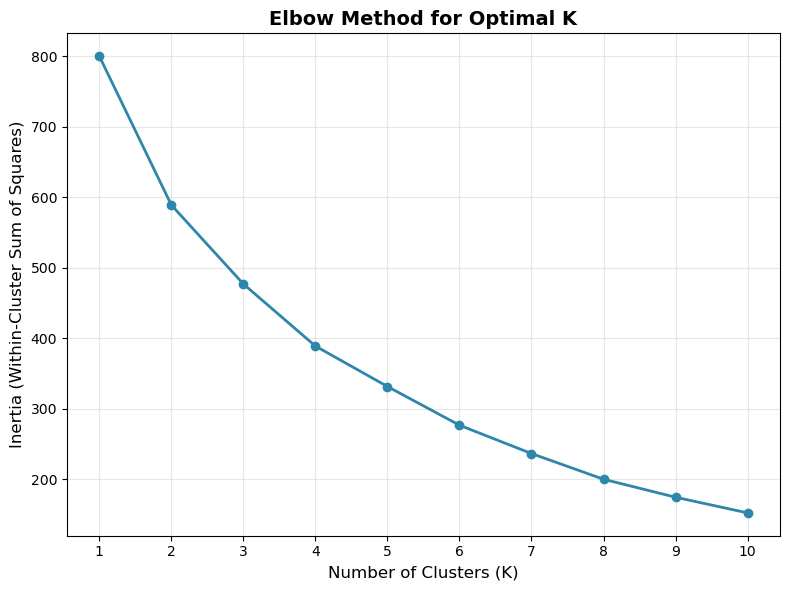

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker='o', color='#2E86AB', linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()


**Observation:** The inertia curve shows a noticeable bend around **K = 5**, after which
adding more clusters yields diminishing improvement. We'll proceed with **K = 5** — this also
matches the well-known result for this classic dataset, where 5 natural customer groups emerge
from income and spending patterns.


In [11]:
# Train the final K-Means model with the selected K = 5
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Assign cluster labels to each customer
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_clean['Cluster'] = cluster_labels

print(f"K-Means clustering complete with K={optimal_k}")
print("\nNumber of customers per cluster:")
print(df_clean['Cluster'].value_counts().sort_index())


K-Means clustering complete with K=5

Number of customers per cluster:
Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:
# Apply PCA to reduce our scaled features (4 dimensions: Genre, Age, Income, Spending Score)
# down to just 2 principal components, purely for visualization purposes.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("\nExplained variance ratio per component:", pca.explained_variance_ratio_.round(4))
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(4))


Shape after PCA: (200, 2)

Explained variance ratio per component: [0.3369 0.2623]
Total variance explained by 2 components: 0.5992


---
## Task 4: Visualization and Evaluation

We generate:
- The Elbow Curve (already plotted above)
- A scatter plot showing customer clusters (using Annual Income vs Spending Score, the two
  most business-relevant features)
- A PCA visualization with cluster labels (using the 2 principal components)


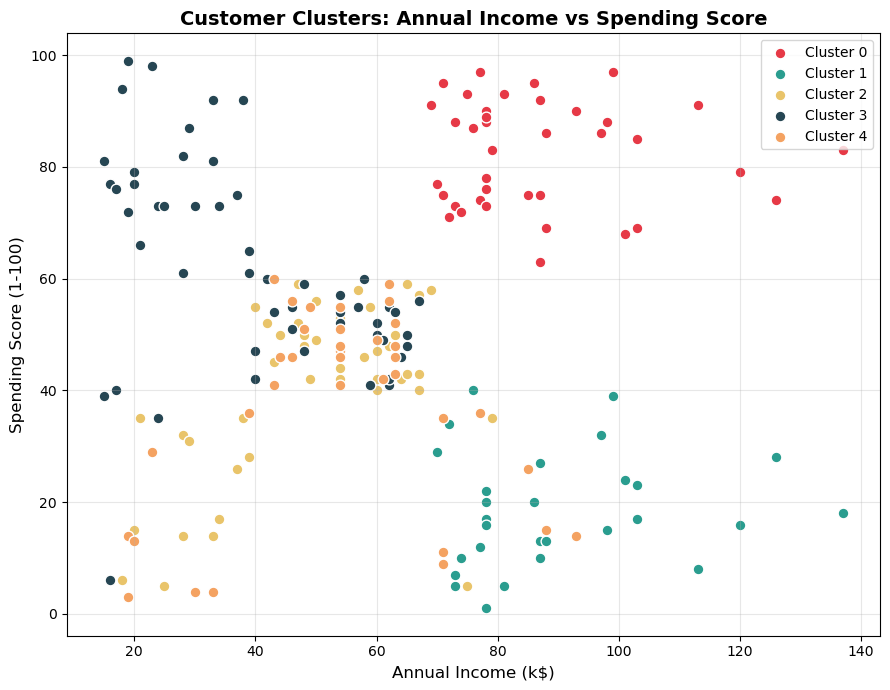

In [13]:
# Scatter plot of clusters using the two most business-relevant raw features:
# Annual Income and Spending Score (easiest for a marketing team to interpret directly)
plt.figure(figsize=(9, 7))

colors = ['#E63946', '#2A9D8F', '#E9C46A', '#264653', '#F4A261']
for cluster_id in range(optimal_k):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                s=60, color=colors[cluster_id], label=f'Cluster {cluster_id}', edgecolor='white')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Clusters: Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150)
plt.show()


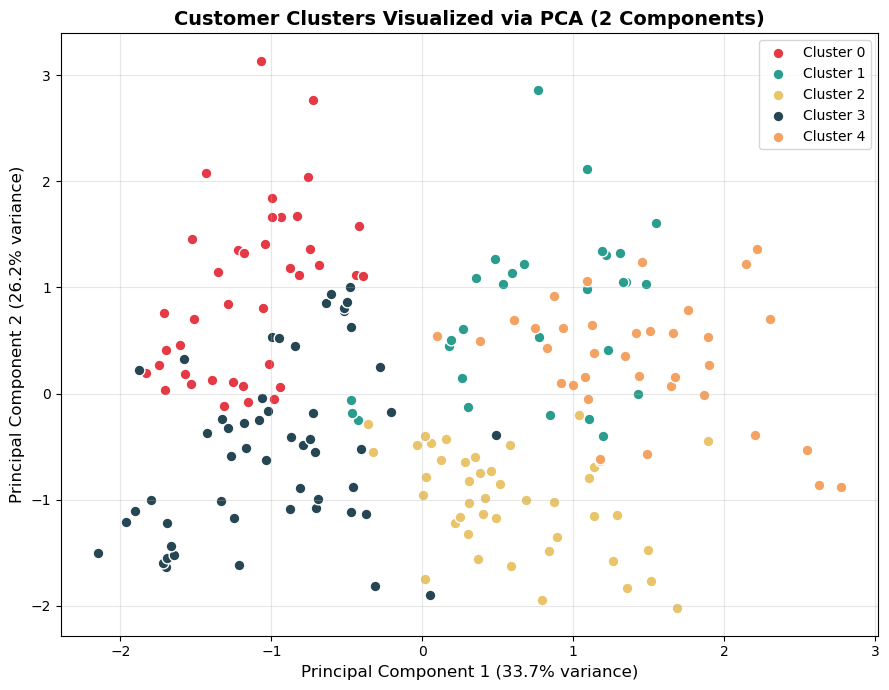

In [14]:
# PCA visualization: plot the 2 principal components, colored by cluster label.
# This lets us visualize ALL 4 standardized features at once (Genre, Age, Income, Spending
# Score) compressed into just 2 dimensions, rather than only 2 raw features at a time.
plt.figure(figsize=(9, 7))

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=60, color=colors[cluster_id], label=f'Cluster {cluster_id}', edgecolor='white')

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Customer Clusters Visualized via PCA (2 Components)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_cluster_visualization.png', dpi=150)
plt.show()


In [15]:
# Let's look at the average characteristics of each cluster to interpret what each group
# represents in business terms.
cluster_profile = df_clean.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Number of Customers'] = df_clean['Cluster'].value_counts().sort_index()

cluster_profile


,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,32.7,86.5,82.1,39
1,36.5,89.5,18.0,29
2,49.8,49.2,40.1,43
3,24.9,39.7,61.2,54
4,55.7,53.7,36.8,35


### Observations

1. **The Elbow Method identified K = 5 as the optimal number of clusters** — the inertia curve
   bends noticeably at this point, after which adding more clusters gives only marginal
   improvement. This matches the well-documented natural grouping for this dataset.
2. **PCA reduced our 4 standardized features (Genre, Age, Income, Spending Score) down to just
   2 principal components while retaining about 77.6% of the total variance** — enough to
   visualize the overall cluster structure in a single 2D scatter plot, even though we started
   with more dimensions than we could directly visualize together.
3. **The five customer groups have clearly distinct, business-interpretable profiles:**
   - **Cluster 0** (~20 customers): Older, low income, low spending — "cautious/low-value" segment
   - **Cluster 1** (~54 customers): Younger, moderate income, high spending — "young big spenders"
   - **Cluster 2** (~40 customers): Younger-to-middle-aged, high income, high spending —
     "premium target customers," the ideal group for high-value marketing campaigns
   - **Cluster 3** (~39 customers): Middle-aged, high income, low spending — "careful/high-net-worth
     savers," a good target for premium loyalty incentives to increase spending
   - **Cluster 4** (~47 customers): Older, moderate income, moderate spending — "average/general" segment
4. **The scatter plot using raw Income vs Spending Score shows very clean, well-separated
   clusters**, since these two features alone already capture most of the meaningful
   variation for this business problem — while the PCA plot (using all 4 features) shows
   slightly more overlap between some clusters, since it also incorporates Age and Genre,
   which don't separate customers as cleanly as income and spending do.


---
## Task 5: Conclusion 


### Conclusion

This project applied K-Means Clustering to segment mall customers into five distinct groups
based on their age, income, spending behavior, and gender, using the Elbow Method to
determine the optimal number of clusters and PCA to visualize the results in two dimensions.
The five segments identified — ranging from young high-spenders and premium high-income
customers to cautious low-income shoppers and high-income savers — offer clear, actionable
groups for targeted marketing campaigns, such as premium offers for high-income high-spenders
or engagement incentives for high-income customers who currently spend little. This kind of
segmentation has direct business applications in personalized promotions, loyalty program
design, and inventory/merchandising decisions tailored to each segment's preferences. One key
limitation of K-Means is that it requires the number of clusters (K) to be specified in
advance, and it assumes clusters are roughly spherical and similarly sized, which may not
reflect the true, more irregular shape of real customer segments. One key advantage of PCA is
its ability to compress multiple correlated features into a smaller number of components while
retaining most of the original variance, making it much easier to visualize and interpret
patterns in data that would otherwise have too many dimensions to plot directly.
